## «Топ-хэви» начальная функция масс — демонстрация на синтетических данных

По статье: Durrant et al. 2026, *"Cosmological simulations of the high-redshift galaxy population adopting a variable stellar initial mass function"*, arXiv:2607.16404 (MNRAS, §2.2 «Variable IMF implementation», Eq. 1-2, Fig. 1-2).

Модель авторов вводит начальную функцию масс (initial mass function, IMF) — ломаный степенной закон вида
$$
\frac{dn}{dM} \propto
\begin{cases}
M^{-1.3}, & 0.1 \le M/M_\odot < 0.5 \\
M^{\alpha}, & 0.5 \le M/M_\odot < 100
\end{cases}
$$
где показатель степени на высокомассовом конце $\alpha$ — не константа, а сигмоидная функция плотности газа $n_{\rm H,birth}$, из которого рождается конкретная звёздная популяция:
$$
\alpha(n_{\rm H,birth}) = \alpha_{\rm high} + \frac{\alpha_{\rm low} - \alpha_{\rm high}}{1 + (n_{\rm H,birth}/n_{\rm H,pivot})^{\gamma}}
$$
Параметры взяты напрямую из статьи (§2.2, стр. 5): $\alpha_{\rm low}=-2.3$ (соответствует IMF Крупы 2001, конвергенция при низкой плотности), $\alpha_{\rm high}=-1.6$ (предельная «топ-хэви» IMF), $\gamma=0.65$, $n_{\rm H,pivot}=30\ {\rm cm^{-3}}$; масса нижнего/верхнего пределов и точка излома — 0.1, 100 и 0.5 $M_\odot$ соответственно.

Ниже — воспроизведение аналитической формы IMF (в стиле Fig. 1 статьи), демонстрация зависимости $\alpha$ от плотности (Eq. 2), генерация синтетической выборки звёздных масс методом обратного преобразования для обоих режимов и числовая проверка утверждения статьи (§2.2.1) о том, что «топ-хэви» IMF даёт примерно вдвое больше прародителей сверхновых коллапса ядра (CCSNe, $M>8\,M_\odot$) на единицу сформированной звёздной массы.

In [1]:
from pathlib import Path

import numpy as np
from scipy import integrate, interpolate
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

OUT_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)


In [2]:
# ============================================================
# IMF functional form (Durrant et al. 2026, Eq. 1) and the
# density-dependent high-mass slope (Eq. 2). Parameter values
# are taken directly from the paper's Section 2.2 / Table 1.
# ============================================================

M_LO, M_PIVOT_MASS, M_HI = 0.1, 0.5, 100.0   # Msun, IMF mass limits + break
X_LOW_MASS = -1.3                             # fixed low-mass slope (< 0.5 Msun)

ALPHA_LOW = -2.3     # low natal-density limit (Kroupa 2001 equivalent)
ALPHA_HIGH = -1.6    # most top-heavy limit adopted in the paper
GAMMA = 0.65          # sigmoid width
N_H_PIVOT = 30.0      # cm^-3, sigmoid pivot density


def alpha_of_density(n_H_birth):
    """Eq. 2: high-mass IMF slope as a sigmoid function of natal gas density."""
    n_H_birth = np.asarray(n_H_birth, dtype=float)
    return ALPHA_HIGH + (ALPHA_LOW - ALPHA_HIGH) / (1.0 + (n_H_birth / N_H_PIVOT) ** GAMMA)


def imf_shape(M, alpha):
    """Unnormalised dn/dM (Eq. 1) for a given high-mass slope alpha."""
    M = np.asarray(M, dtype=float)
    # continuity at the 0.5 Msun break: A * 0.5^-1.3 = B * 0.5^alpha
    B_over_A = M_PIVOT_MASS ** (X_LOW_MASS - alpha)
    low = M ** X_LOW_MASS
    high = B_over_A * M ** alpha
    return np.where(M < M_PIVOT_MASS, low, high)


def normalisation_constant(alpha, n_points=20000):
    """Solve for A so that the IMF integrates to 1 Msun of stars formed
    over [M_LO, M_HI], matching the paper's own normalisation (Fig. 1 caption)."""
    M_grid = np.logspace(np.log10(M_LO), np.log10(M_HI), n_points)
    shape = imf_shape(M_grid, alpha)
    mass_integral = integrate.trapezoid(M_grid * shape, M_grid)
    return 1.0 / mass_integral


def imf_dndM(M, alpha):
    """Normalised dn/dM: number of stars per unit mass, per 1 Msun formed."""
    A = normalisation_constant(alpha)
    return A * imf_shape(M, alpha)


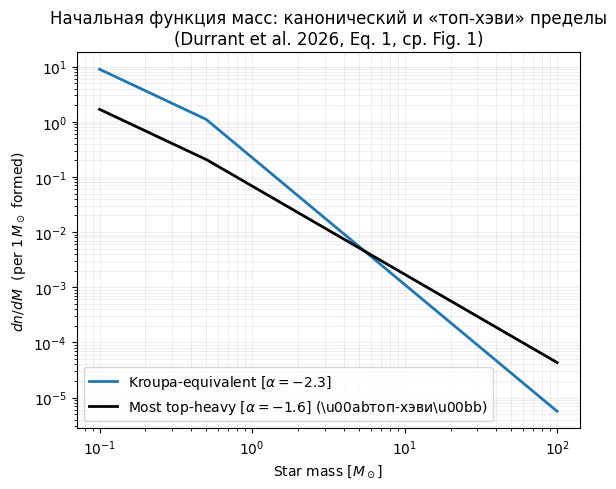

In [3]:
# ============================================================
# Reproduce Fig. 1 of the paper: dn/dM for the Kroupa-equivalent
# (alpha = -2.3) and most top-heavy (alpha = -1.6) IMFs.
# ============================================================

M_grid = np.logspace(np.log10(M_LO), np.log10(M_HI), 500)

fig, ax = plt.subplots(figsize=(6, 5))
for alpha, label, color in [
    (ALPHA_LOW, r"Kroupa-equivalent [$\alpha=-2.3$]", "#1f77b4"),
    (ALPHA_HIGH, r"Most top-heavy [$\alpha=-1.6$] (\u00abтоп-хэви\u00bb)", "black"),
]:
    ax.plot(M_grid, imf_dndM(M_grid, alpha), color=color, lw=2, label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Star mass [$M_\odot$]")
ax.set_ylabel(r"$dn/dM$  (per $1\,M_\odot$ formed)")
ax.set_title("Начальная функция масс: канонический и «топ-хэви» пределы\n(Durrant et al. 2026, Eq. 1, ср. Fig. 1)")
ax.legend()
ax.grid(alpha=0.2, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "imf_shapes.png", dpi=140)
plt.show()


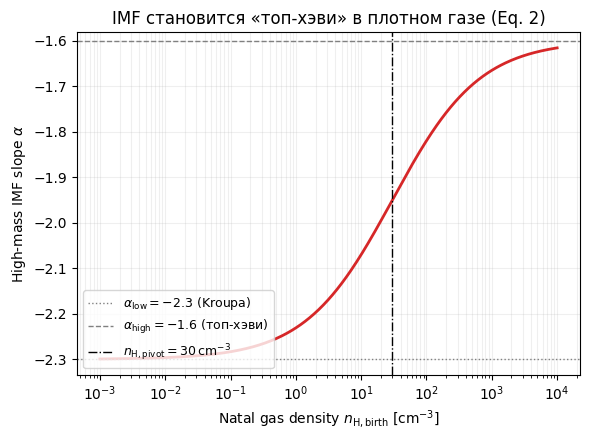

In [4]:
# ============================================================
# Eq. 2: how the high-mass slope alpha depends on natal gas
# density. The paper notes natal density spans ~7 orders of
# magnitude across the simulated galaxy population.
# ============================================================

n_H_grid = np.logspace(-3, 4, 400)
alpha_grid = alpha_of_density(n_H_grid)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(n_H_grid, alpha_grid, color="#d62728", lw=2)
ax.axhline(ALPHA_LOW, color="gray", ls=":", lw=1, label=r"$\alpha_{\rm low}=-2.3$ (Kroupa)")
ax.axhline(ALPHA_HIGH, color="gray", ls="--", lw=1, label=r"$\alpha_{\rm high}=-1.6$ (топ-хэви)")
ax.axvline(N_H_PIVOT, color="black", ls="-.", lw=1, label=r"$n_{\rm H,pivot}=30\,{\rm cm^{-3}}$")
ax.set_xscale("log")
ax.set_xlabel(r"Natal gas density $n_{\rm H,birth}$ [cm$^{-3}$]")
ax.set_ylabel(r"High-mass IMF slope $\alpha$")
ax.set_title("IMF становится «топ-хэви» в плотном газе (Eq. 2)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.2, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "alpha_vs_density.png", dpi=140)
plt.show()


In [5]:
# ============================================================
# Synthetic dataset: draw stellar masses from each IMF via
# inverse-transform sampling (numeric CDF -> quantile function).
# ============================================================

def build_sampler(alpha, n_points=20000):
    M_grid = np.logspace(np.log10(M_LO), np.log10(M_HI), n_points)
    dndM = imf_shape(M_grid, alpha)               # unnormalised number density
    cdf = integrate.cumulative_trapezoid(dndM, M_grid, initial=0.0)
    cdf /= cdf[-1]
    # invert: quantile function u -> M, via interpolation on the numeric CDF
    inv_cdf = interpolate.interp1d(cdf, M_grid, bounds_error=False,
                                    fill_value=(M_LO, M_HI))
    return inv_cdf


def sample_masses(alpha, n_stars, rng):
    inv_cdf = build_sampler(alpha)
    u = rng.uniform(0.0, 1.0, size=n_stars)
    return inv_cdf(u)


N_STARS = 200_000
masses_kroupa = sample_masses(ALPHA_LOW, N_STARS, rng)
masses_topheavy = sample_masses(ALPHA_HIGH, N_STARS, rng)

print(f"Synthetic sample drawn: {N_STARS:,} stars per IMF")
print(f"Kroupa    -> total mass {masses_kroupa.sum():,.0f} Msun, "
      f"median {np.median(masses_kroupa):.3f} Msun")
print(f"Top-heavy -> total mass {masses_topheavy.sum():,.0f} Msun, "
      f"median {np.median(masses_topheavy):.3f} Msun")


Synthetic sample drawn: 200,000 stars per IMF
Kroupa    -> total mass 127,642 Msun, median 0.276 Msun
Top-heavy -> total mass 521,653 Msun, median 0.397 Msun


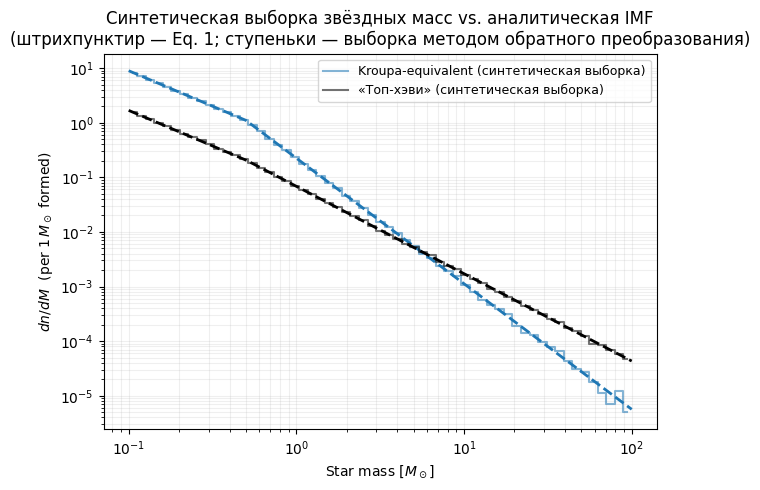

In [6]:
# ============================================================
# Compare the sampled synthetic mass distributions against the
# analytic dn/dM curves (sanity check + visual demonstration).
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 5))
bins = np.logspace(np.log10(M_LO), np.log10(M_HI), 60)

for masses, alpha, label, color in [
    (masses_kroupa, ALPHA_LOW, "Kroupa-equivalent (синтетическая выборка)", "#1f77b4"),
    (masses_topheavy, ALPHA_HIGH, "«Топ-хэви» (синтетическая выборка)", "black"),
]:
    hist, edges = np.histogram(masses, bins=bins, density=False)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total_mass_formed = masses.sum()
    # normalise the sampled histogram to "per 1 Msun formed", to match imf_dndM's units
    dndM_sampled = hist / widths / total_mass_formed
    ax.step(centers, dndM_sampled, where="mid", color=color, alpha=0.55, lw=1.5, label=label)
    ax.plot(M_grid, imf_dndM(M_grid, alpha), color=color, lw=2, ls="--")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Star mass [$M_\odot$]")
ax.set_ylabel(r"$dn/dM$  (per $1\,M_\odot$ formed)")
ax.set_title("Синтетическая выборка звёздных масс vs. аналитическая IMF\n"
              "(штрихпунктир — Eq. 1; ступеньки — выборка методом обратного преобразования)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "imf_synthetic_vs_analytic.png", dpi=140)
plt.show()


In [7]:
# ============================================================
# Quantitative check against the paper's own claim (Sec. 2.2.1):
# "stellar populations with a top-heavy IMF (-1.8 <= alpha <= -1)
# yield roughly twice as many CCSNe as those with a Kroupa IMF,
# assuming all stars of mass > 8 Msun are CCSN progenitors."
# ============================================================

M_CCSN = 8.0  # Msun, core-collapse supernova progenitor threshold used in the paper

def n_ccsn_progenitors_per_solar_mass(alpha):
    """Analytic number of stars with M > 8 Msun, per 1 Msun of stars formed."""
    M_grid_fine = np.logspace(np.log10(M_CCSN), np.log10(M_HI), 5000)
    return integrate.trapezoid(imf_dndM(M_grid_fine, alpha), M_grid_fine)


n_ccsn_kroupa = n_ccsn_progenitors_per_solar_mass(ALPHA_LOW)
n_ccsn_topheavy = n_ccsn_progenitors_per_solar_mass(ALPHA_HIGH)

# same statistic from the synthetic samples, as a cross-check
frac_ccsn_kroupa_sample = np.mean(masses_kroupa > M_CCSN) * N_STARS / masses_kroupa.sum()
frac_ccsn_topheavy_sample = np.mean(masses_topheavy > M_CCSN) * N_STARS / masses_topheavy.sum()

print("Прародители CCSN (M > 8 Msun) на 1 Msun сформированных звёзд:")
print(f"  Kroupa (analytic)     : {n_ccsn_kroupa:.5f}   (sample: {frac_ccsn_kroupa_sample:.5f})")
print(f"  Top-heavy (analytic)  : {n_ccsn_topheavy:.5f}   (sample: {frac_ccsn_topheavy_sample:.5f})")
print(f"  Ratio top-heavy/Kroupa: {n_ccsn_topheavy / n_ccsn_kroupa:.2f}"
      f"  (sample ratio: {frac_ccsn_topheavy_sample / frac_ccsn_kroupa_sample:.2f})")
print()
print("Ожидание из статьи (§2.2.1): 'roughly twice as many CCSNe' -> ratio ~ 2.")


Прародители CCSN (M > 8 Msun) на 1 Msun сформированных звёзд:
  Kroupa (analytic)     : 0.01113   (sample: 0.01119)
  Top-heavy (analytic)  : 0.02556   (sample: 0.02548)
  Ratio top-heavy/Kroupa: 2.30  (sample ratio: 2.28)

Ожидание из статьи (§2.2.1): 'roughly twice as many CCSNe' -> ratio ~ 2.


### Итог

Численная проверка (аналитическая и по синтетической выборке) воспроизводит заявленный в статье эффект: у «топ-хэви» IMF ($\alpha=-1.6$) число прародителей сверхновых с массой выше $8\,M_\odot$ на каждую сформированную солнечную массу звёзд получается примерно в **два раза больше**, чем у канонической IMF Крупы ($\alpha=-2.3$) — именно поэтому смещение начальной функции масс в сторону массивных звёзд самосогласованно тянет за собой рост энергии обратной связи от сверхновых, выхода металлов и производства пыли, о чём говорится в тексте статьи и в пояснительной сноске к статье [«Слишком много ярких галактик...»](../2607.16404_edited.md).